# Preliminary Analysis & Design Motivation

Reproduces all figures and statistical tests from the preliminary simulation (baseline traders only, `fvi_v2/`) and the full v7 simulation (`results_v7/`).

**Run from the `bse/` root directory.**

---
### Contents
1. Setup
2. Preliminary data — profit heatmap
3. ZIP: inventory as profit driver (scatter)
4. Volatility regime preference (bar chart)
5. Statistical Table 1 — profit: high-vol vs low-vol (Welch t-test)
6. Inventory over session by condition (4-panel timeseries)
7. Statistical Table 2 — final inventory: high-vol vs low-vol (Mann-Whitney U)
8. Full v7 data — design motivation (4-panel)
9. CUSTOM MtM profit over session (4-panel)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats
from IPython.display import display

# ── Paths (relative to bse/ root) ────────────────────────────────────────────
HERE     = os.getcwd()          # assumes notebook is run from bse/
PRE_CSV  = os.path.join(HERE, 'data', 'preliminary_results.csv')
PRE_INV  = os.path.join(HERE, 'data', 'preliminary_inventory.csv')
V7_CSV   = os.path.join(HERE, 'data', 'simulation_results.csv')
TS_CSV   = os.path.join(HERE, 'data', 'custom_profit_timeseries.csv')
SAVE_DIR = os.path.join(HERE, 'figures')
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Plot style (matches bayesian_analysis.ipynb) ──────────────────────────────
plt.rcParams.update({
    'text.usetex':       False,
    'font.family':       'serif',
    'font.serif':        ['DejaVu Serif'],
    'axes.labelsize':    18,
    'font.size':         11,
    'legend.fontsize':   11,
    'xtick.labelsize':   14,
    'ytick.labelsize':   14,
    'axes.titlesize':    14,
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
    'grid.linewidth':    0.5,
})

COLORS = {
    'ZIP':    '#2196F3',
    'PRSH':   '#4CAF50',
    'ZIC':    '#9C27B0',
    'CUSTOM': '#FF6B35',
    'SNPR':   '#795548',
    'SHVR':   '#607D8B',
    'GVWY':   '#9E9E9E',
}
CONDITIONS   = ['stable', 'shock_up', 'shock_down', 'multi_regime']
COND_LABELS  = ['Stable', 'Shock Up', 'Shock Down', 'Multi-Regime']
HIGH_CONDS   = ['shock_up',  'multi_regime']
LOW_CONDS    = ['stable',    'shock_down']

print('Setup complete.')

Setup complete.


In [2]:
# ── Load preliminary data ────────────────────────────────────────────────────
df  = pd.read_csv(PRE_CSV)
inv = pd.read_csv(PRE_INV)
print(f'Preliminary: {len(df):,} rows | traders: {sorted(df.ttype.unique())} | conditions: {sorted(df.condition.unique())}')

Preliminary: 18,000 rows | traders: ['GVWY', 'PRSH', 'SHVR', 'SNPR', 'ZIC', 'ZIP'] | conditions: ['multi_regime', 'shock_down', 'shock_up', 'stable']


## 2. Profit Heatmap (all baseline traders × all conditions)

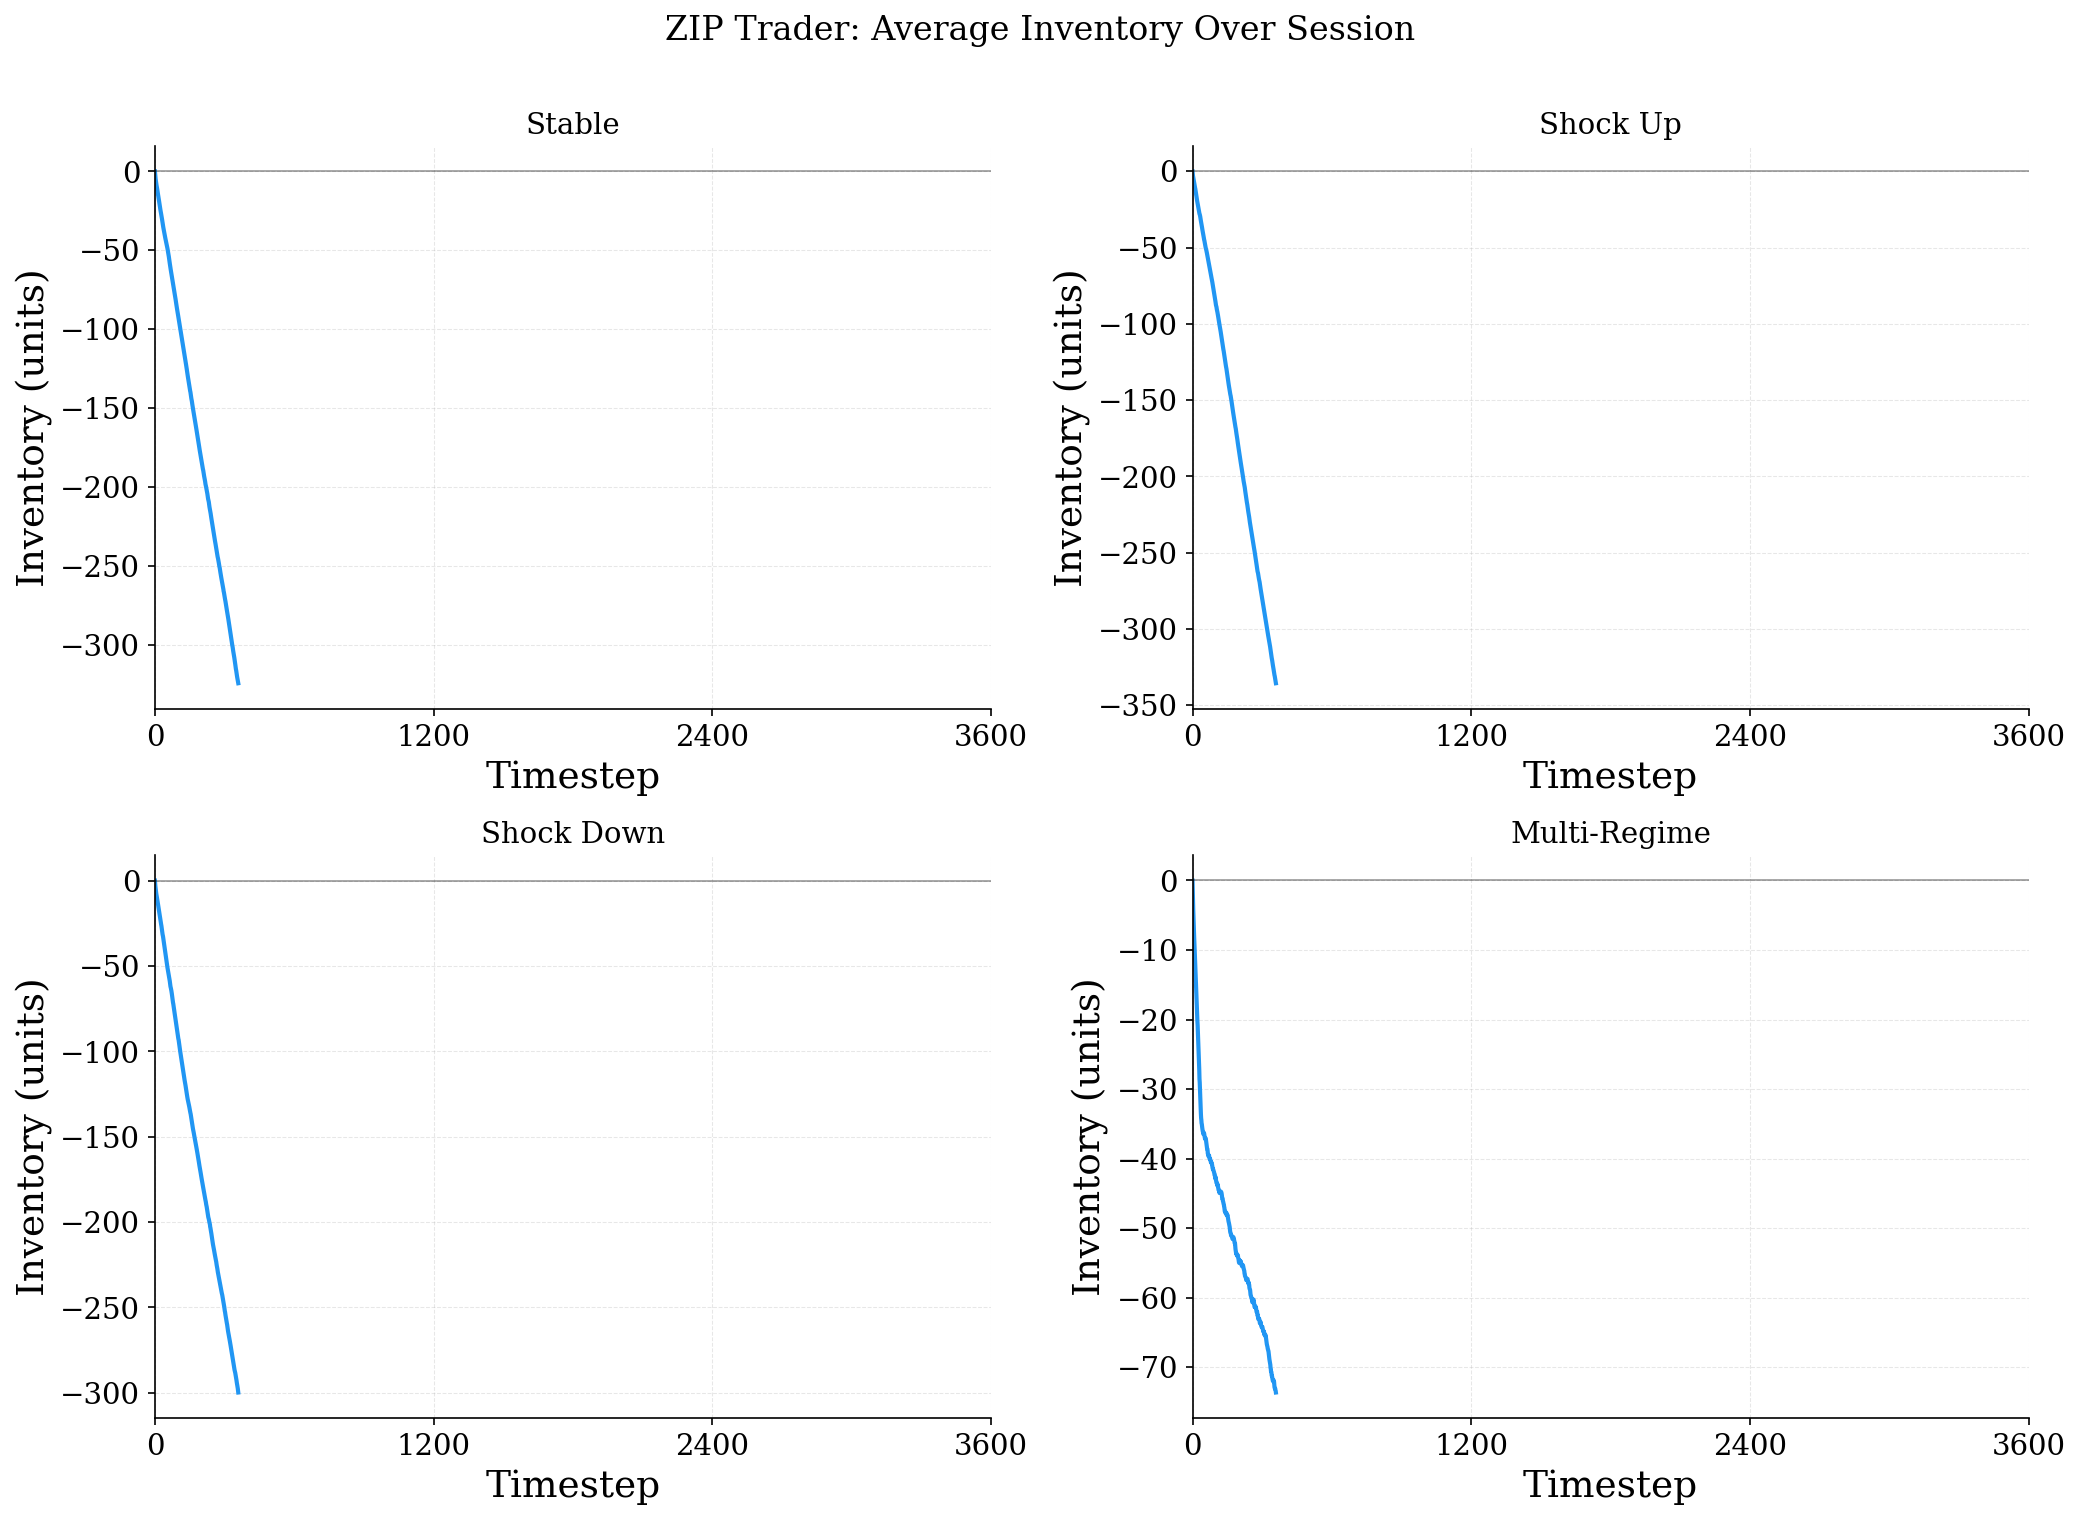

In [5]:
records = []
for (cond, ts), grp in inv[inv.ttype == 'ZIP'].groupby(['condition', 'timestep']):
    vals = grp['mean_inv'].values
    mean = vals.mean()
    records.append({'condition': cond, 'timestep': ts, 'mean': mean})
agg = pd.DataFrame(records).sort_values(['condition', 'timestep'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, cond, label in zip(axes, CONDITIONS, COND_LABELS):
    sub = agg[agg.condition == cond]
    ts_vals = sub['timestep'].values
    ax.plot(ts_vals, sub['mean'].values, color=COLORS['ZIP'], linewidth=2.0)
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.4)
    ax.set_title(label)
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Inventory (units)')
    ax.set_xlim(0, 3600)
    ax.set_xticks([0, 1200, 2400, 3600])

fig.suptitle('ZIP Trader: Average Inventory Over Session', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## 3. ZIP: Inventory as Profit Driver

In [ ]:
zip_df = df[df.ttype == 'ZIP']
c_means = [
    (c,
     zip_df[zip_df.condition == c]['final_inventory'].mean(),
     zip_df[zip_df.condition == c]['final_profit'].mean())
    for c in CONDITIONS
]

dot_colors = ['#546E7A', '#F44336', '#1565C0', '#7B1FA2']

fig, ax = plt.subplots(figsize=(7, 5))

for (c, inv_m, prf_m), col in zip(c_means, dot_colors):
    ax.scatter(inv_m, prf_m, color=col, s=160, zorder=5,
               edgecolors='white', linewidth=1.2,
               label=COND_LABELS[CONDITIONS.index(c)])
    ax.annotate(COND_LABELS[CONDITIONS.index(c)],
                xy=(inv_m, prf_m),
                xytext=(inv_m + 8, prf_m + 150),
                fontsize=9, color=col)

# Regression line through condition means
invs = np.array([x[1] for x in c_means])
prfs = np.array([x[2] for x in c_means])
m, b = np.polyfit(invs, prfs, 1)
x_line = np.linspace(invs.min() - 20, invs.max() + 20, 100)
ax.plot(x_line, m * x_line + b, '--', color='grey', linewidth=1.2, alpha=0.6)

r = np.corrcoef(invs, prfs)[0, 1]

ax.axvline(0, color='black', linewidth=0.7, alpha=0.4)
ax.axhline(0, color='black', linewidth=0.7, alpha=0.4)
ax.set_xlabel('Mean Final Inventory (units)')
ax.set_ylabel('Profit')
ax.set_title('ZIP: Inventory as Profit Driver')
plt.tight_layout()
#plt.savefig(os.path.join(SAVE_DIR, 'Pre_ZIP_inventory_scatter.png'), bbox_inches='tight')
plt.show()

## 4. Volatility Regime Preference

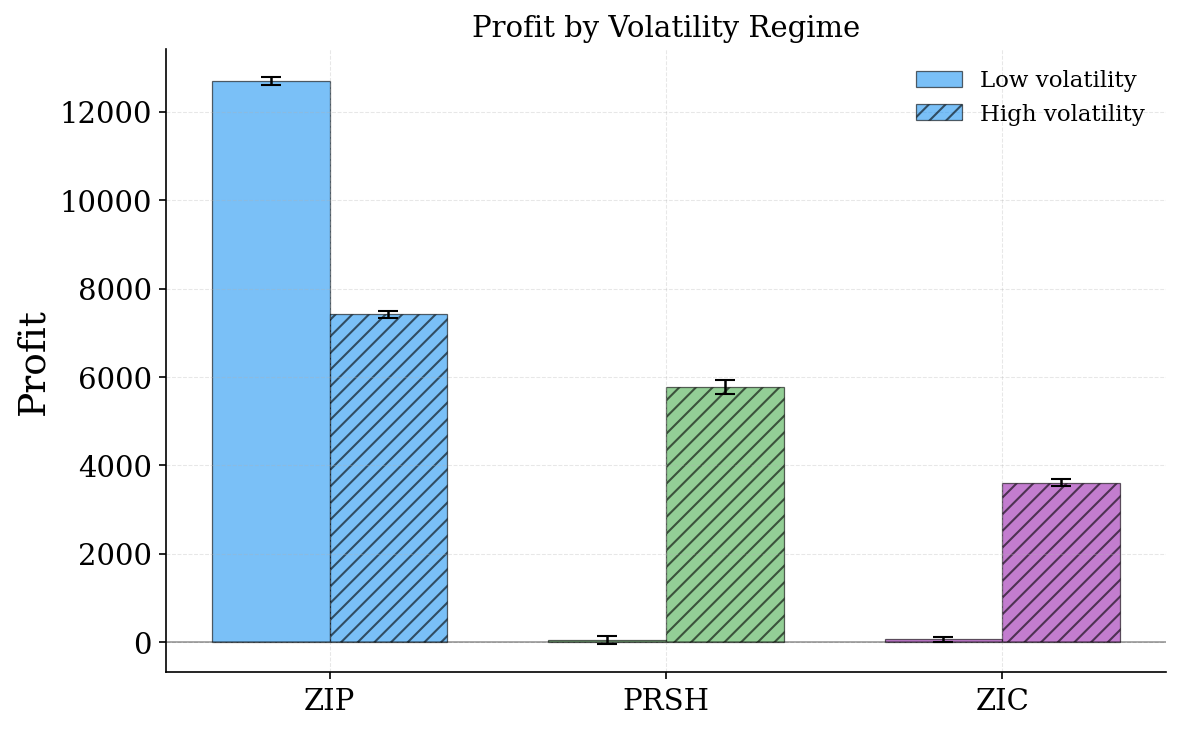

In [ ]:
TRADERS = ['ZIP', 'PRSH', 'ZIC']
x = np.arange(len(TRADERS))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

for i, (label, conds, alpha, hatch) in enumerate([
    ('Low volatility',  LOW_CONDS,  0.90, ''),
    ('High volatility', HIGH_CONDS, 0.60, '///'),
]):
    means = [df[(df.ttype == t) & (df.condition.isin(conds))]['final_profit'].mean()
             for t in TRADERS]
    sems  = [df[(df.ttype == t) & (df.condition.isin(conds))]['final_profit'].sem()
             for t in TRADERS]
    ax.bar(x + (i - 0.5) * w, means, w,
           color=[COLORS[t] for t in TRADERS],
           alpha=alpha, hatch=hatch, edgecolor='k', linewidth=0.6,
           yerr=sems, capsize=5, error_kw={'linewidth': 1.2},
           label=label)

ax.axhline(0, color='black', linewidth=0.8, alpha=0.4)
ax.set_xticks(x)
ax.set_xticklabels(TRADERS)
ax.set_ylabel('Profit')
ax.set_title('Profit by Volatility Regime')
ax.legend(frameon=False)
plt.tight_layout()
#plt.savefig(os.path.join(SAVE_DIR, 'Volatility_regime.png'), bbox_inches='tight')
plt.show()

## 5. Statistical Table 1 — Profit: High-vol vs Low-vol

**Test:** Welch's independent samples t-test (unequal variances assumed)  
**Groups:** High volatility = Shock Up + Multi-Regime; Low volatility = Stable + Shock Down  
**n per group per trader:** 1,500 (150 trials × 2 conditions × 5 traders)

In [6]:
rows = []
for t in TRADERS:
    hi = df[(df.ttype == t) & (df.condition.isin(HIGH_CONDS))]['final_profit']
    lo = df[(df.ttype == t) & (df.condition.isin(LOW_CONDS))]['final_profit']
    stat, p = stats.ttest_ind(hi, lo, equal_var=False)
    d = (hi.mean() - lo.mean()) / np.sqrt((hi.std()**2 + lo.std()**2) / 2)
    rows.append({
        'Trader':          t,
        'Low-vol mean':    f'{lo.mean():,.0f}',
        'High-vol mean':   f'{hi.mean():,.0f}',
        't-statistic':     f'{stat:+.3f}',
        'p-value':         f'{p:.2e}',
        "Cohen's d":       f'{d:+.3f}',
    })

tbl1 = pd.DataFrame(rows).set_index('Trader')
display(tbl1)

,Low-vol mean,High-vol mean,t-statistic,p-value,Cohen's d
Trader,,,,,
ZIP,"12,688","7,419",-45.018,0.00e+00,-1.644
PRSH,55,"5,775",+31.643,5.21e-185,+1.155
ZIC,70,"3,611",+35.994,3.15e-230,+1.314


## 6. Inventory Over Session by Condition (4-panel)

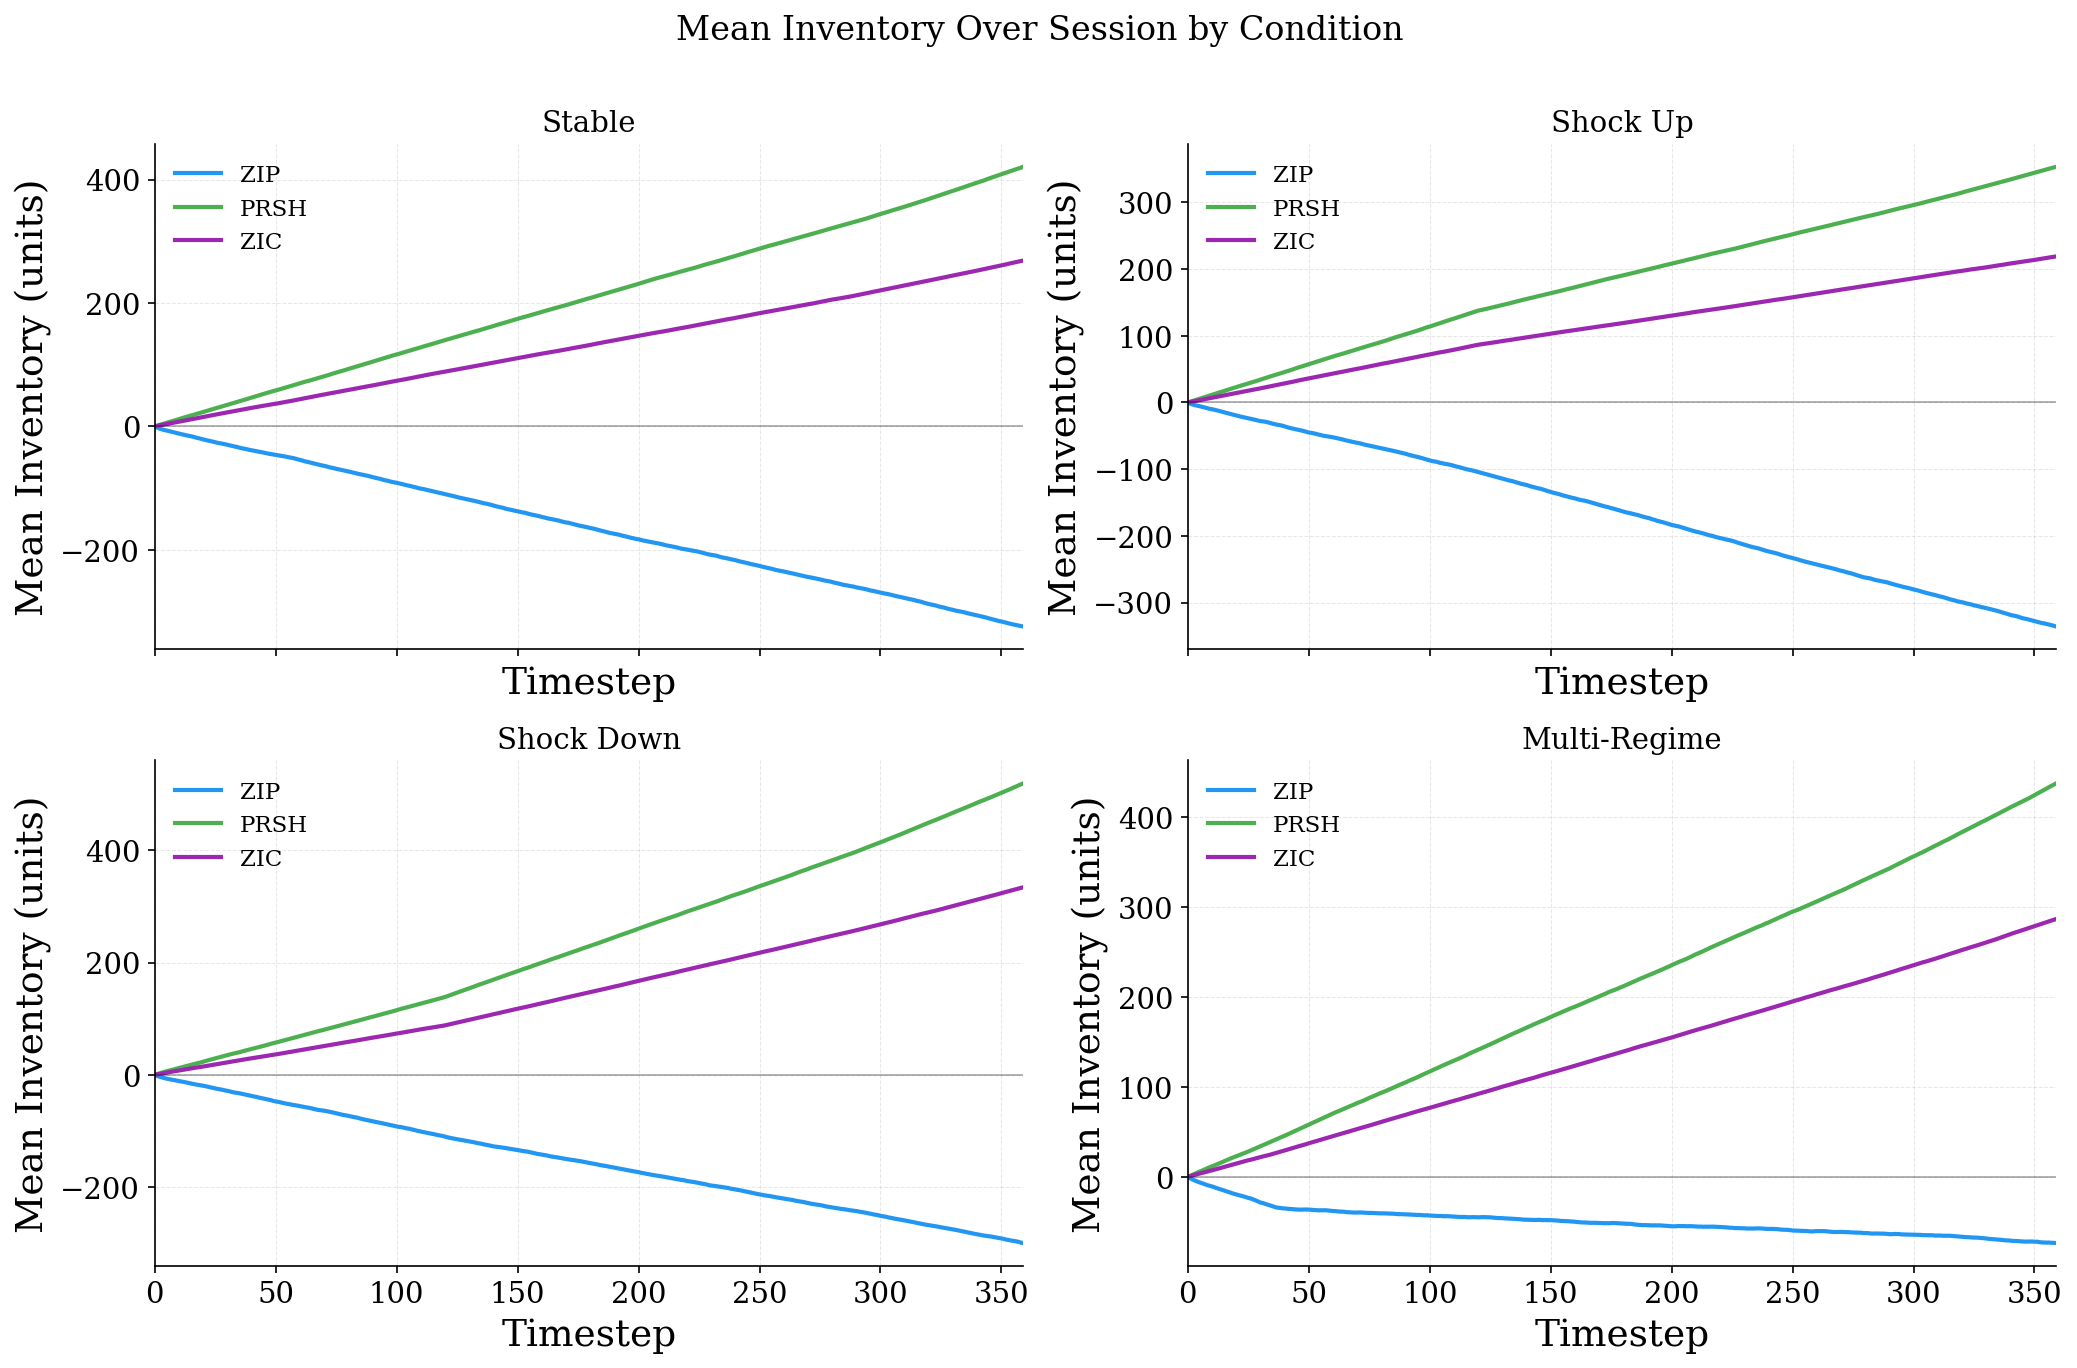

In [7]:
inv_focus = inv[inv.ttype.isin(TRADERS)].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
axes = axes.flatten()

for ax, cond, label in zip(axes, CONDITIONS, COND_LABELS):
    sub = inv_focus[inv_focus.condition == cond]
    agg = (
        sub.groupby(['ttype', 'timestep'])['mean_inv']
           .mean()
           .reset_index()
    )
    for t in TRADERS:
        ts = agg[agg.ttype == t].sort_values('timestep')
        ax.plot(ts['timestep'], ts['mean_inv'],
                color=COLORS[t], linewidth=2.0, label=t)

    ax.axhline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.35)
    ax.set_title(label)
    ax.set_ylabel('Mean Inventory (units)')
    ax.set_xlabel('Timestep')
    ax.set_xlim(0, inv_focus['timestep'].max())
    ax.legend(frameon=False, loc='best')

fig.suptitle('Mean Inventory Over Session by Condition', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'Inventory_by_condition.png'), bbox_inches='tight')
plt.show()

## 7. Statistical Table 2 — Final Inventory: High-vol vs Low-vol

**Test:** Mann-Whitney U (non-parametric; final inventory distributions are non-normal)  
**Groups:** same as Table 1

In [8]:
rows = []
for t in TRADERS:
    hi = df[(df.ttype == t) & (df.condition.isin(HIGH_CONDS))]['final_inventory']
    lo = df[(df.ttype == t) & (df.condition.isin(LOW_CONDS))]['final_inventory']
    U, p = stats.mannwhitneyu(hi, lo, alternative='two-sided')
    d = (hi.mean() - lo.mean()) / np.sqrt((hi.std()**2 + lo.std()**2) / 2)
    rows.append({
        'Trader':          t,
        'Low-vol mean inv': f'{lo.mean():+.1f}',
        'High-vol mean inv': f'{hi.mean():+.1f}',
        'U-statistic':     f'{U:,.0f}',
        'p-value':         f'{p:.2e}',
        "Cohen's d":       f'{d:+.3f}',
    })

tbl2 = pd.DataFrame(rows).set_index('Trader')
display(tbl2)

,Low-vol mean inv,High-vol mean inv,U-statistic,p-value,Cohen's d
Trader,,,,,
ZIP,-312.8,-205.1,"1,482,640",2.30e-51,+0.461
PRSH,+471.6,+396.6,"932,962",5.69e-16,-0.347
ZIC,+302.6,+253.5,"543,518",1.05e-132,-1.023


## 8. Full v7 Simulation — Design Motivation (4-panel)

Uses `results_v7/all_results.csv` (includes CUSTOM trader with Bayesian-optimised parameters).

In [9]:
df7 = pd.read_csv(V7_CSV)
print(f'v7: {len(df7):,} rows | traders: {sorted(df7.ttype.unique())}')

v7: 21,000 rows | traders: ['CUSTOM', 'GVWY', 'PRSH', 'SHVR', 'SNPR', 'ZIC', 'ZIP']


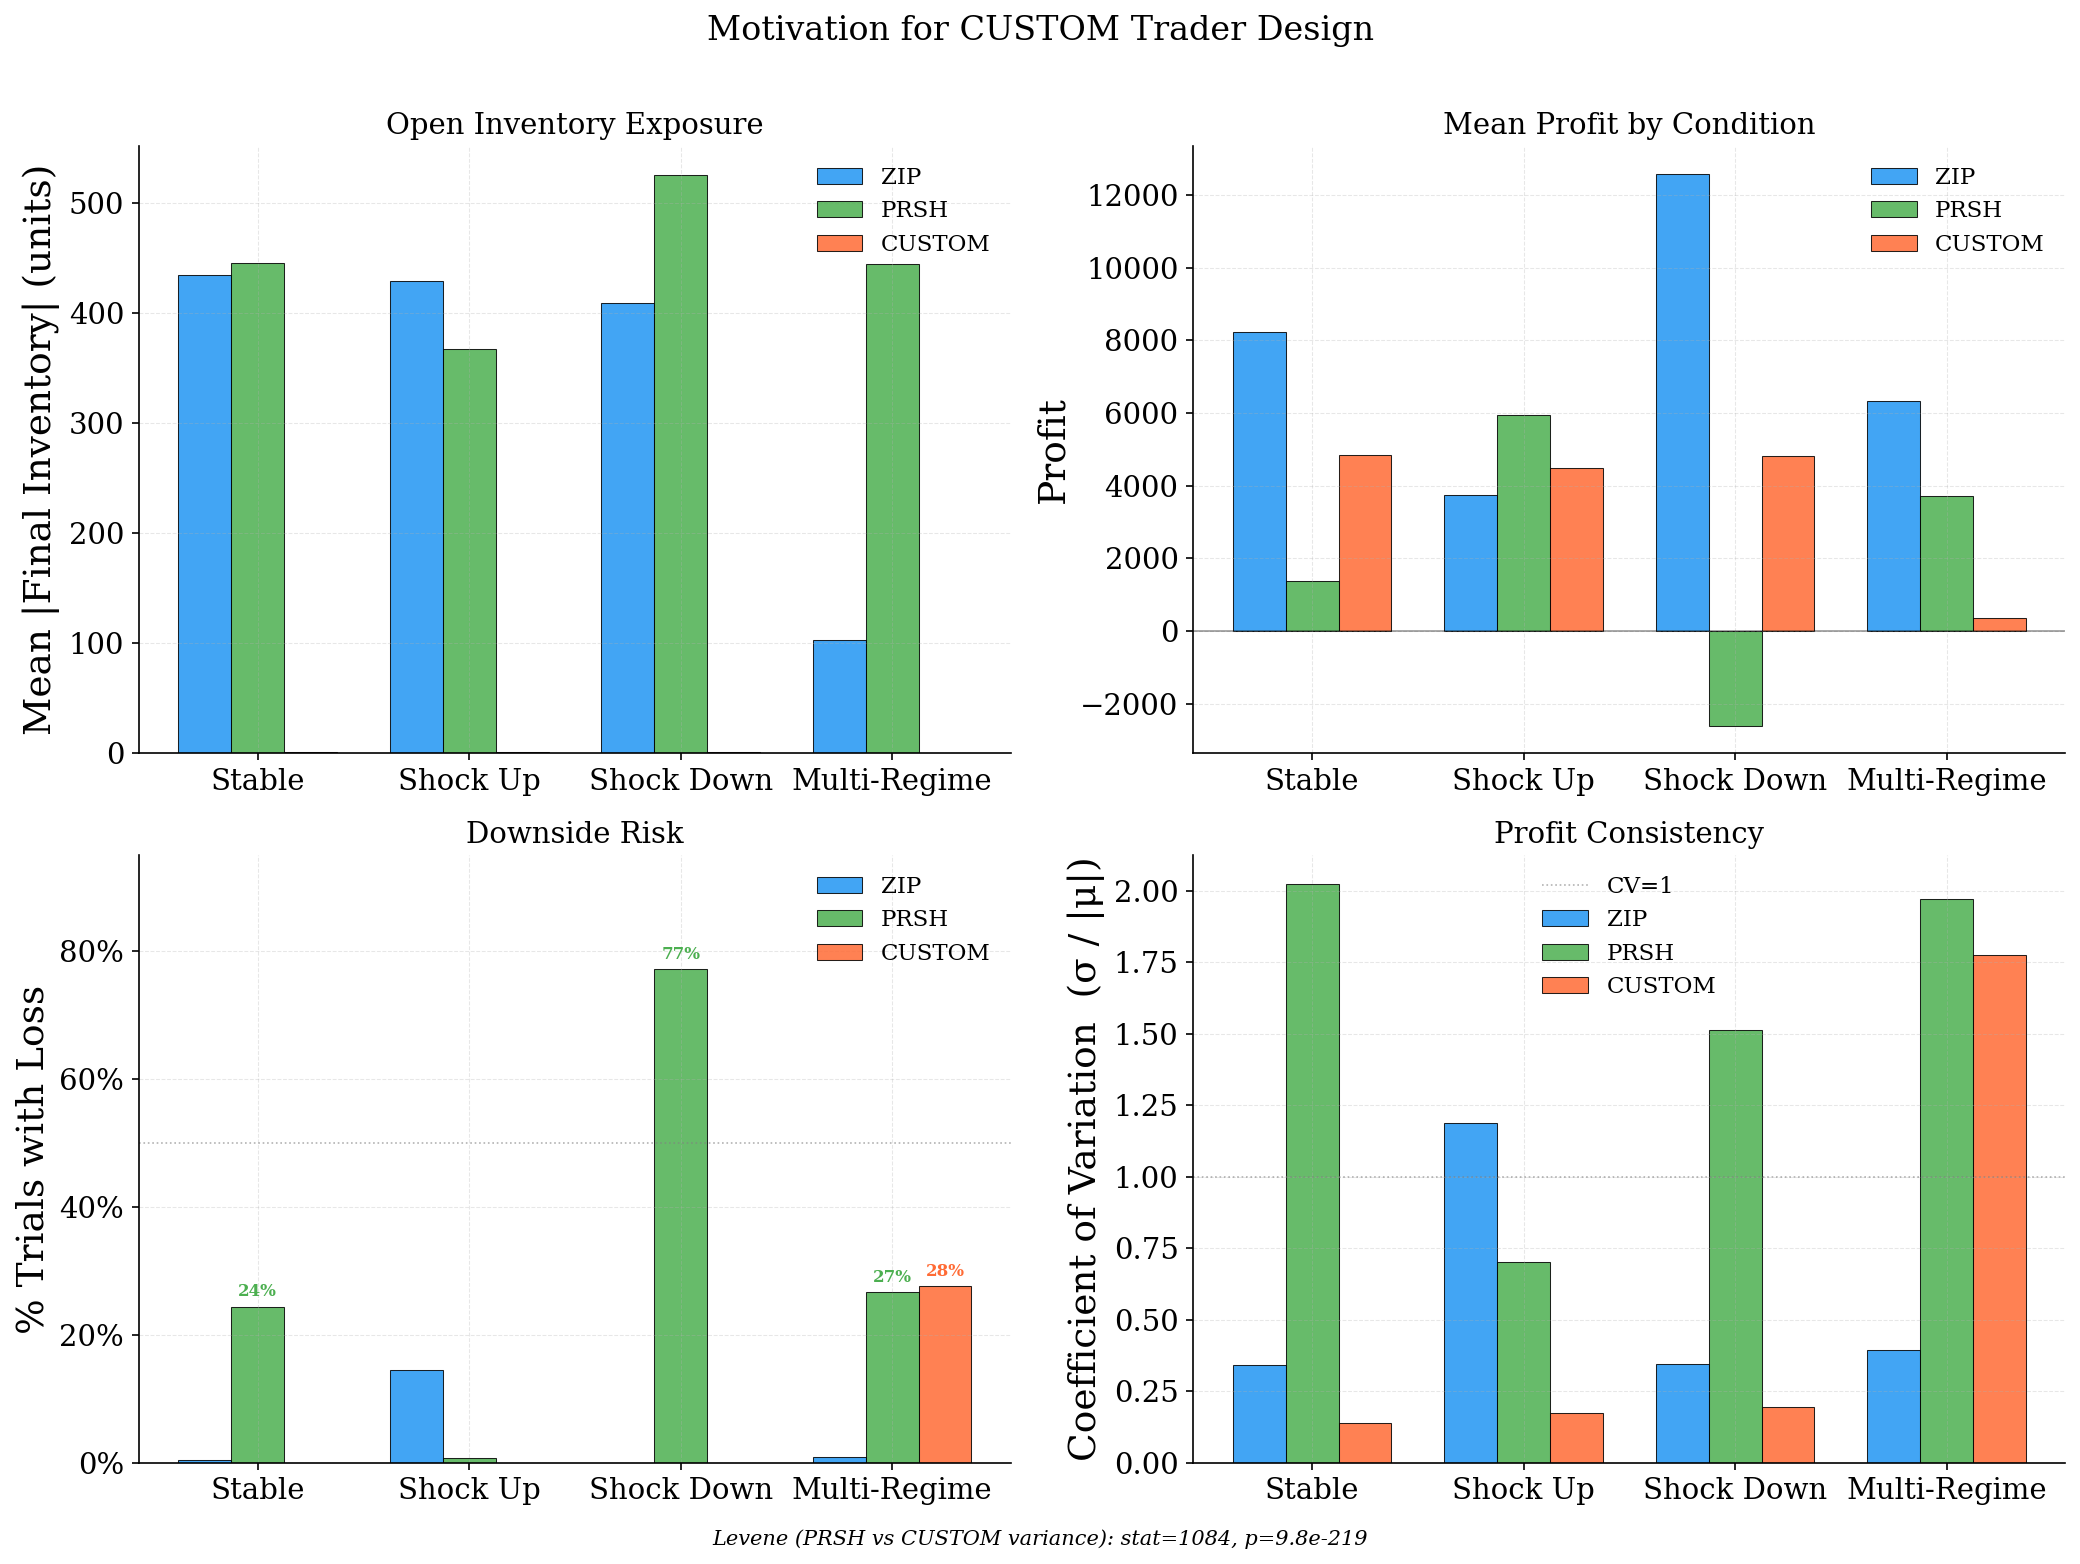

In [10]:
FOCUS = ['ZIP', 'PRSH', 'CUSTOM']

inv_data  = {t: [df7[(df7.ttype==t)&(df7.condition==c)]['final_inventory'].abs().mean() for c in CONDITIONS] for t in FOCUS}
mean_data = {t: [df7[(df7.ttype==t)&(df7.condition==c)]['final_profit'].mean()          for c in CONDITIONS] for t in FOCUS}
pct_neg   = {t: [(df7[(df7.ttype==t)&(df7.condition==c)]['final_profit']<0).mean()*100   for c in CONDITIONS] for t in FOCUS}
cv_data   = {t: [] for t in FOCUS}
for t in FOCUS:
    for c in CONDITIONS:
        sub = df7[(df7.ttype==t)&(df7.condition==c)]['final_profit']
        cv_data[t].append(sub.std()/abs(sub.mean()) if sub.mean()!=0 else np.nan)

x = np.arange(len(CONDITIONS))
w = 0.25
offsets = np.linspace(-(len(FOCUS)-1)*w/2, (len(FOCUS)-1)*w/2, len(FOCUS))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Panel 1: Inventory exposure
ax = axes[0]
for i, t in enumerate(FOCUS):
    ax.bar(x + offsets[i], inv_data[t], w, label=t,
           color=COLORS[t], alpha=0.85, edgecolor='k', linewidth=0.5)
ax.set_xticks(x); ax.set_xticklabels(COND_LABELS)
ax.set_ylabel('Mean |Final Inventory| (units)')
ax.set_title('Open Inventory Exposure')
ax.legend(frameon=False)

# Panel 2: Mean profit per condition
ax = axes[1]
for i, t in enumerate(FOCUS):
    ax.bar(x + offsets[i], mean_data[t], w, label=t,
           color=COLORS[t], alpha=0.85, edgecolor='k', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8, alpha=0.4)
ax.set_xticks(x); ax.set_xticklabels(COND_LABELS)
ax.set_ylabel('Profit')
ax.set_title('Mean Profit by Condition')
ax.legend(frameon=False)

# Panel 3: % negative-profit trials
ax = axes[2]
for i, t in enumerate(FOCUS):
    ax.bar(x + offsets[i], pct_neg[t], w, label=t,
           color=COLORS[t], alpha=0.85, edgecolor='k', linewidth=0.5)
    for xpos, val in zip(x + offsets[i], pct_neg[t]):
        if val > 15:
            ax.text(xpos, val + 1, f'{val:.0f}%', ha='center', va='bottom',
                    fontsize=8, fontweight='bold', color=COLORS[t])
ax.axhline(50, color='grey', linewidth=0.8, linestyle=':', alpha=0.6)
ax.set_xticks(x); ax.set_xticklabels(COND_LABELS)
ax.set_ylabel('% Trials with Loss')
ax.set_title('Downside Risk')
ax.set_ylim(0, 95)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(frameon=False)

# Panel 4: Coefficient of variation
ax = axes[3]
for i, t in enumerate(FOCUS):
    ax.bar(x + offsets[i], cv_data[t], w, label=t,
           color=COLORS[t], alpha=0.85, edgecolor='k', linewidth=0.5)
ax.axhline(1.0, color='grey', linewidth=0.8, linestyle=':', alpha=0.6, label='CV=1')
ax.set_xticks(x); ax.set_xticklabels(COND_LABELS)
ax.set_ylabel('Coefficient of Variation  (σ / |μ|)')
ax.set_title('Profit Consistency')
ax.legend(frameon=False)

# Levene test
lev_stat, lev_p = stats.levene(df7[df7.ttype=='PRSH']['final_profit'],
                                df7[df7.ttype=='CUSTOM']['final_profit'])
fig.text(0.5, -0.01,
         f'Levene (PRSH vs CUSTOM variance): stat={lev_stat:.0f}, p={lev_p:.1e}',
         ha='center', fontsize=10, style='italic')

fig.suptitle('Motivation for CUSTOM Trader Design', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'Design_motivation.png'), bbox_inches='tight')
plt.show()

## 9. CUSTOM MtM Profit Over Session (4-panel)

Requires `results_v7/custom_profit_timeseries.csv` — generated by `run_custom_timeseries.py`.

In [11]:
ts_df = pd.read_csv(TS_CSV)
print(f'Timeseries: {len(ts_df):,} rows | {ts_df["trial"].nunique()} trials | {ts_df["condition"].nunique()} conditions')

Timeseries: 360,000 rows | 50 trials | 4 conditions


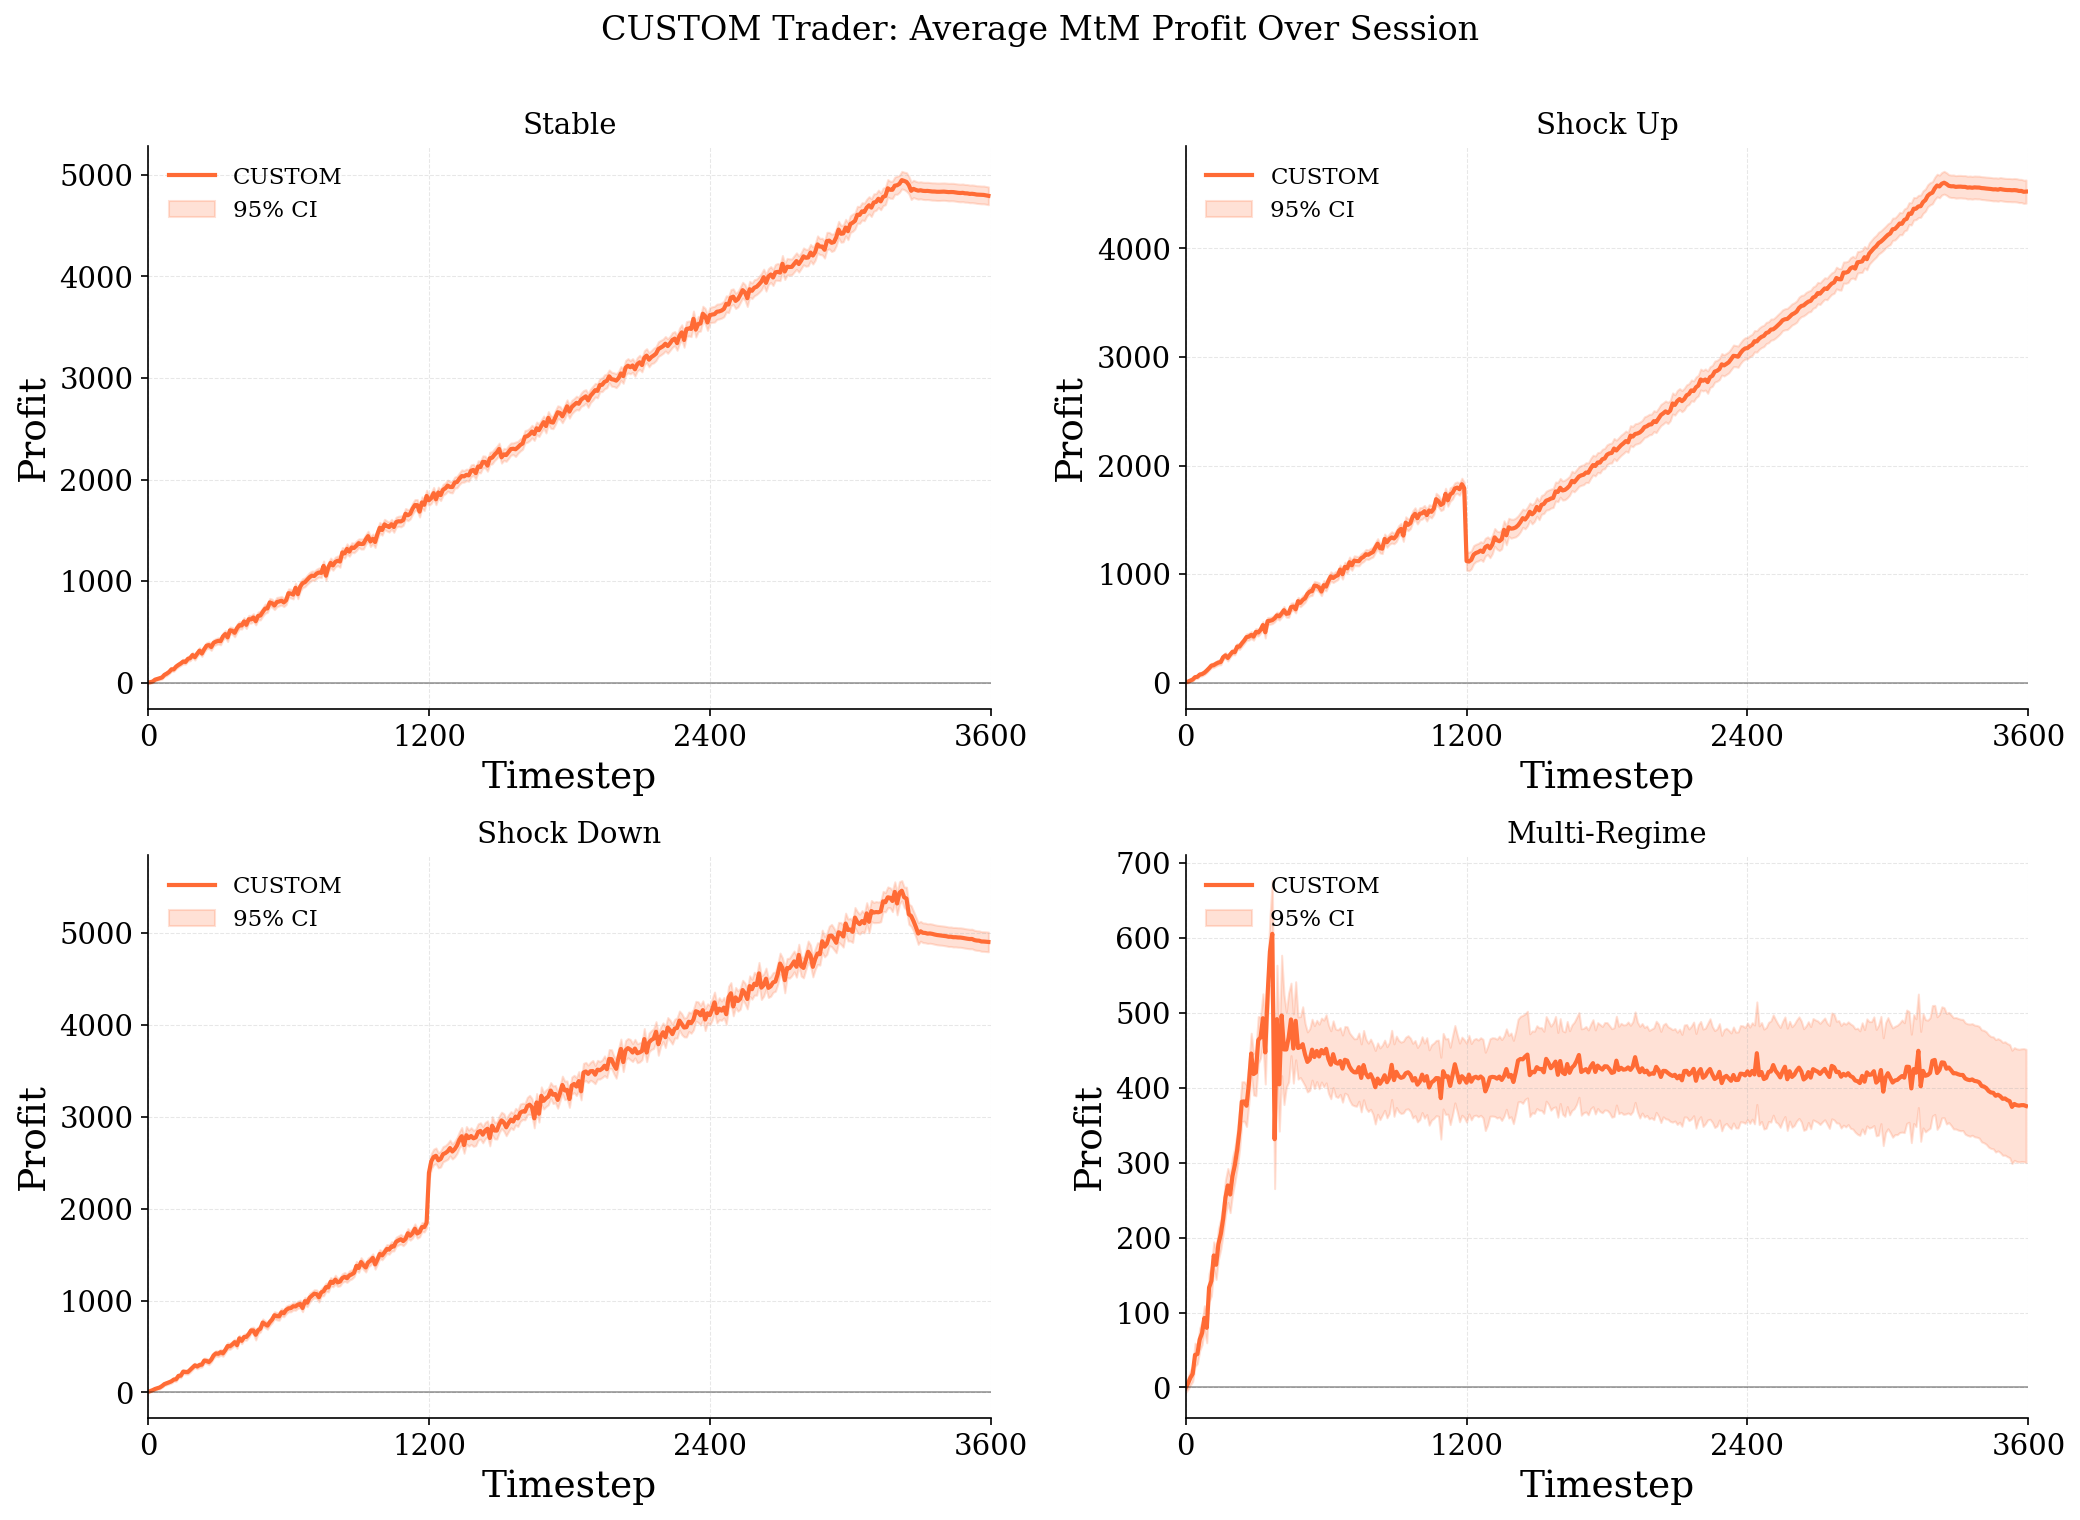

In [12]:
# Aggregate: mean ± 95% CI across all trials and traders per (condition, timestep)
records = []
for (cond, ts), grp in ts_df.groupby(['condition', 'timestep']):
    vals = grp['mtm_profit'].values
    mean = vals.mean()
    sem  = vals.std(ddof=1) / np.sqrt(len(vals))
    records.append({'condition': cond, 'timestep': ts,
                    'mean': mean, 'lo': mean - 1.96*sem, 'hi': mean + 1.96*sem})
agg = pd.DataFrame(records).sort_values(['condition', 'timestep'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, cond, label in zip(axes, CONDITIONS, COND_LABELS):
    sub = agg[agg.condition == cond]
    ts_vals = sub['timestep'].values
    ax.plot(ts_vals, sub['mean'].values, color=COLORS['CUSTOM'], linewidth=2.0, label='CUSTOM')
    ax.fill_between(ts_vals, sub['lo'].values, sub['hi'].values,
                    color=COLORS['CUSTOM'], alpha=0.20, label='95% CI')
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.4)
    ax.set_title(label)
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Profit')
    ax.set_xlim(0, 3600)
    ax.set_xticks([0, 1200, 2400, 3600])
    ax.legend(frameon=False, loc='upper left')

fig.suptitle('CUSTOM Trader: Average MtM Profit Over Session', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'CUSTOM_profit_timeseries.png'), bbox_inches='tight')
plt.show()